<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

In [3]:
!nvidia-smi

Tue Jun  2 02:46:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# CIFAR Code Along with CNN
The <a href='https://en.wikipedia.org/wiki/CIFAR-10'>CIFAR-10</a> dataset is similar to MNIST, except that instead of one color channel (grayscale) there are three channels (RGB).<br>
Where an MNIST image has a size of (1,28,28), CIFAR images are (3,32,32). There are 10 categories an image may fall under:
0. airplane
1. automobile
2. bird
3. cat
4. deer
5. dog
6. frog
7. horse
8. ship
9. truck

As with the previous code along, make sure to watch the theory lectures! You'll want to be comfortable with:
* convolutional layers
* filters/kernels
* pooling
* depth, stride and zero-padding

## Perform standard imports

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

In [7]:
from sklearn.metrics import confusion_matrix

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'svg'

## Load the CIFAR-10 dataset
PyTorch makes the CIFAR-10 train and test datasets available through <a href='https://pytorch.org/docs/stable/torchvision/index.html'><tt><strong>torchvision</strong></tt></a>. The first time they're called, the datasets will be downloaded onto your computer to the path specified. From that point, torchvision will always look for a local copy before attempting another download.<br>The set contains 50,000 train and 10,000 test images.

Refer to the previous section for explanations of transformations, batch sizes and <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader'><tt><strong>DataLoader</strong></tt></a>.

In [9]:
transform = transforms.ToTensor()
train_data = datasets.CIFAR10(root = "../Data" , train = True , download = True , transform = transform)
test_data = datasets.CIFAR10(root = "../Data" , train = False , download = True , transform = transform)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


In [10]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [11]:
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [12]:
len(train_data) , len(test_data)

(50000, 10000)

### Create loaders

In [13]:
torch.manual_seed(101)

train_loader = DataLoader(train_data , batch_size = 10 , shuffle = True )
test_loader = DataLoader(test_data , batch_size = 10 , shuffle = False)

In [14]:
len(train_loader) , len(test_loader)

(5000, 1000)

In [15]:
for images , labels in train_loader:
    break

In [16]:
images.shape , labels.shape

(torch.Size([10, 3, 32, 32]), torch.Size([10]))

In [17]:
len(images)

10

In [18]:
images[0].shape

torch.Size([3, 32, 32])

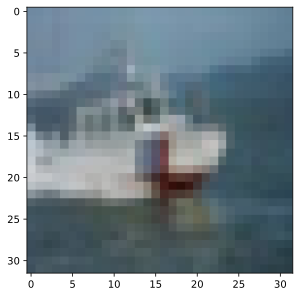

In [19]:
k = np.random.randint(0,10)
plt.imshow(images[k].numpy().transpose(1,2,0))
plt.show()

### Define strings for labels
Since the `batch_size = 10`, so we have to print out 10 labels for each batch of images.
We can call the labels whatever we want, so long as they appear in the order of 'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'. Here we're using `5-character` labels padded with spaces so that our reports line up later.

In [20]:
class_names = ['plane', '  car', ' bird', '  cat', ' deer', '  dog', ' frog', 'horse', ' ship', 'truck']
class_names

['plane',
 '  car',
 ' bird',
 '  cat',
 ' deer',
 '  dog',
 ' frog',
 'horse',
 ' ship',
 'truck']

$\color{tomato}{\text{We don't want to use the variable name "class" here, as it would overwrite Python's built-in keyword.}}$

## View a batch of images

In [21]:
np.set_printoptions(formatter = dict(int = lambda x: f"{x:5}")) # to widen the printed array

In [22]:
# Grab the first batch of 10 images
for images , labels in train_loader:
    break

In [23]:
labels

tensor([5, 4, 0, 9, 1, 2, 2, 4, 2, 2])

In [24]:
labels.numpy()

array([    5,     4,     0,     9,     1,     2,     2,     4,     2,
           2])

In [25]:
print("labels:" , labels.numpy())

labels: [    5     4     0     9     1     2     2     4     2     2]


In [26]:
np.array([class_names[i] for i in labels])

array(['  dog', ' deer', 'plane', 'truck', '  car', ' bird', ' bird',
       ' deer', ' bird', ' bird'], dtype='<U5')

In [27]:
print("Class:" , np.array([class_names[i] for i in labels]))

Class: ['  dog' ' deer' 'plane' 'truck' '  car' ' bird' ' bird' ' deer' ' bird'
 ' bird']


In [28]:
print("Class:" , *np.array([class_names[i] for i in labels]))

Class:   dog  deer plane truck   car  bird  bird  deer  bird  bird


In [29]:
images.shape

torch.Size([10, 3, 32, 32])

In [30]:
images[0].shape

torch.Size([3, 32, 32])

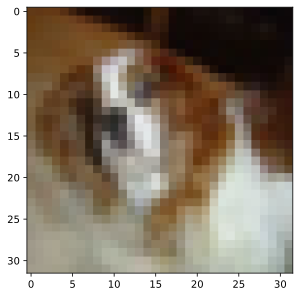

In [31]:
plt.imshow(images[0].numpy().transpose(1,2,0))

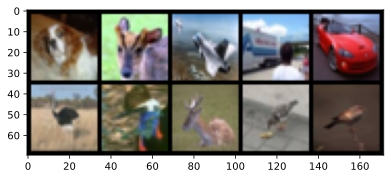

In [32]:
# Print the images
im = make_grid(images , nrow = 5) # nrow can be set up to the batch_size
plt.imshow(im.numpy().transpose(1,2,0))
plt.show()

Now, let's wrap up all the three in one block of code:

Label: [    9     1     9     2     0     5     1     0     9     8]
Class:  truck   car truck  bird plane   dog   car plane truck  ship


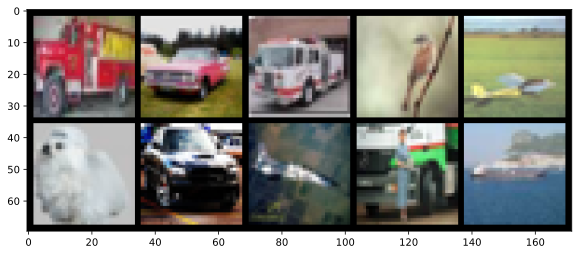

In [33]:
np.set_printoptions(formatter=dict(int=lambda x: f'{x:5}')) # to widen the printed array

# Grab the first batch of 10 images
for images,labels in train_loader:
    break

# Print the labels
print('Label:', labels.numpy())
print('Class: ', *np.array([class_names[i] for i in labels]))

# Print the images
im = make_grid(images, nrow=5)  # the default nrow is 8
plt.figure(figsize=(10,4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

## Define the model
In the previous section we used two convolutional layers and two pooling layers before feeding data through a fully connected hidden layer to our output. The model follows CONV/RELU/POOL/CONV/RELU/POOL/FC/RELU/FC. We'll use the same format here.

The only changes are:
* take in 3-channel images instead of 1-channel
* adjust the size of the fully connected input<br>

Our first convolutional layer will have 3 input channels, 6 output channels, a kernel size of 3 (resulting in a 3x3 filter), and a stride length of 1 pixel.<br>These are passed in as <tt>nn.Conv2d(3,6,3,1)</tt>

In [34]:
conv1 = nn.Conv2d(in_channels = 3 , out_channels = 6 , kernel_size = 3 , stride = 1)
conv2 = nn.Conv2d(in_channels = 6 , out_channels = 16 , kernel_size = 3 , stride = 1)

In [35]:
images.shape

torch.Size([10, 3, 32, 32])

In [36]:
conv1(images).shape

torch.Size([10, 6, 30, 30])

In [37]:
first_layer = F.relu(conv1(images))
first_layer.shape

torch.Size([10, 6, 30, 30])

In [38]:
first_pool = F.max_pool2d(F.relu(conv1(images)) , kernel_size = 2 , stride = 2)
first_pool.shape

torch.Size([10, 6, 15, 15])

In [39]:
conv2 = nn.Conv2d(in_channels = 6 , out_channels = 16 , kernel_size = 3 , stride = 1)
second_layer = conv2(first_pool)
second_layer.shape

torch.Size([10, 16, 13, 13])

In [40]:
second_pool = F.max_pool2d(F.relu(second_layer) , kernel_size = 2 , stride = 2)
second_pool.shape

torch.Size([10, 16, 6, 6])

```python
fc1 = nn.Linear(input_features = 16*6*6 , output_features = 120)
fc2 = nn.Linear(input_features = 120 , output_features = 84)
fc3 = nn.Linear(input_features = 84 , output_features = 10)
```

In [41]:
class ConvolutionalNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 3 , out_channels = 6 , kernel_size = 3 , stride = 1)
        self.conv2 = nn.Conv2d(in_channels = 6 , out_channels = 16 , kernel_size = 3 , stride = 1)
        self.fc1 = nn.Linear(in_features = 16*6*6 , out_features = 120)
        self.fc2 = nn.Linear(in_features = 120 , out_features = 84)
        self.fc3 = nn.Linear(in_features = 84 , out_features = 10)



    def forward(self , x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x , kernel_size = 2 , stride = 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x , kernel_size = 2 , stride = 2)
        x = x.view(-1 , 16*6*6)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = F.log_softmax(x , dim = 1)
        return x

<div class="alert alert-info"><strong>Why <tt>(6x6x16)</tt> instead of <tt>(5x5x16)</tt>?</strong><br>
With MNIST the kernels and pooling layers resulted in $\;(((28−2)/2)−2)/2=5.5 \;$ which rounds down to 5 pixels per side.<br>
With CIFAR the result is $\;(((32-2)/2)-2)/2 = 6.5\;$ which rounds down to 6 pixels per side.</div>

In [42]:
torch.manual_seed(101)
model = ConvolutionalNetwork()
model = model.to(device)
model

ConvolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Including the bias terms for each layer, the total number of parameters being trained is:
\begin{split}
& (3\times6\times3\times3)+6 \\
& + (6\times16\times3\times3)+16 \\
& + (576\times120)+120+ \\
& + (120\times84)+84 \\
& + (84\times10)+10 \\
&= 162+6+864+16+69120+120+10080+84+840+10 \\
&= 81,302
\end{split}

In [43]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6,}')
    print(f'______\n{sum(params):>6,}')

In [44]:
count_parameters(model)

   162
     6
   864
    16
69,120
   120
10,080
    84
   840
    10
______
81,302


## Define loss function & optimizer

In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Train the model
This time we'll feed the data directly into the model without flattening it first.<br>
<div class="alert alert-info"><font color=blue><strong>OPTIONAL: </strong>In the event that training takes too long, you can interrupt the kernel, skip ahead to the bottom of the notebook, and load a trained version of the model that's been saved in this folder.</font></div>

In [48]:
import time
start_time = time.time()

epochs = 15
train_losses = []
train_correct = []

test_losses = []
test_correct = []

for epoch in range(epochs):
    trn_corr = 0
    tst_corr = 0

    # Run the training batches
    for batch_index_train, (X_train, y_train) in enumerate(train_loader):
        batch_index_train += 1

        #Transform X_train & y_train to GPU
        X_train = X_train.to(device)
        y_train = y_train.to(device)

        # Apply the model
        y_pred = model(X_train) # we don't flatten X-train here
        loss_train = criterion(y_pred, y_train)

        # Tally the number of correct predictions
        train_predicted = torch.max(y_pred.data, 1)[1]
        train_batch_corr = (train_predicted == y_train).sum()
        trn_corr += train_batch_corr

        # Update parameters
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        # Print interim results
        if batch_index_train%1000 == 0:
            print(f'epoch: {epoch:2}  batch: {batch_index_train:4} [{10*batch_index_train:6}/50000]  loss: {loss_train.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*batch_index_train):7.3f}%')

    train_losses.append(loss_train)
    train_correct.append(trn_corr)

    # Run the testing batches
    with torch.no_grad():
        for batch_index_test, (X_test, y_test) in enumerate(test_loader):

            #Transform X_test & y_test to GPU
            X_test = X_test.to(device)
            y_test = y_test.to(device)

            # Apply the model
            y_val = model(X_test)
            loss_test = criterion(y_val, y_test)

            # Tally the number of correct predictions
            test_predicted = torch.max(y_val.data, 1)[1]
            tst_corr += (test_predicted == y_test).sum()

        test_losses.append(loss_test)
        test_correct.append(tst_corr)

end_time = time.time()
print(f'\nDuration: {(end_time - start_time)/60:.0f} minutes & {end_time - start_time:.0f} seconds') # print the time elapsed

epoch:  0  batch: 1000 [ 10000/50000]  loss: 1.45295858  accuracy:  24.270%
epoch:  0  batch: 2000 [ 20000/50000]  loss: 1.49258780  accuracy:  30.235%
epoch:  0  batch: 3000 [ 30000/50000]  loss: 2.09530234  accuracy:  34.170%
epoch:  0  batch: 4000 [ 40000/50000]  loss: 2.16466236  accuracy:  36.695%
epoch:  0  batch: 5000 [ 50000/50000]  loss: 1.81406558  accuracy:  38.724%
epoch:  1  batch: 1000 [ 10000/50000]  loss: 1.15280509  accuracy:  48.160%
epoch:  1  batch: 2000 [ 20000/50000]  loss: 1.39264846  accuracy:  48.735%
epoch:  1  batch: 3000 [ 30000/50000]  loss: 1.23619008  accuracy:  49.280%
epoch:  1  batch: 4000 [ 40000/50000]  loss: 0.79721487  accuracy:  49.935%
epoch:  1  batch: 5000 [ 50000/50000]  loss: 0.94680691  accuracy:  50.418%
epoch:  2  batch: 1000 [ 10000/50000]  loss: 1.06014538  accuracy:  54.290%
epoch:  2  batch: 2000 [ 20000/50000]  loss: 1.05034614  accuracy:  54.560%
epoch:  2  batch: 3000 [ 30000/50000]  loss: 0.93838006  accuracy:  54.907%
epoch:  2  b

## Optional: Save the model
This will save your trained model, without overwriting the saved model we have provided called <strong>CIFAR10-CNN-Model-master.pt</strong>

In [49]:
torch.save(model.state_dict(), 'CIFAR10-CNN-Model.pt')

## Plot the loss and accuracy comparisons

In [50]:
len(torch.stack(train_losses).cpu().detach().numpy().round(2))

15

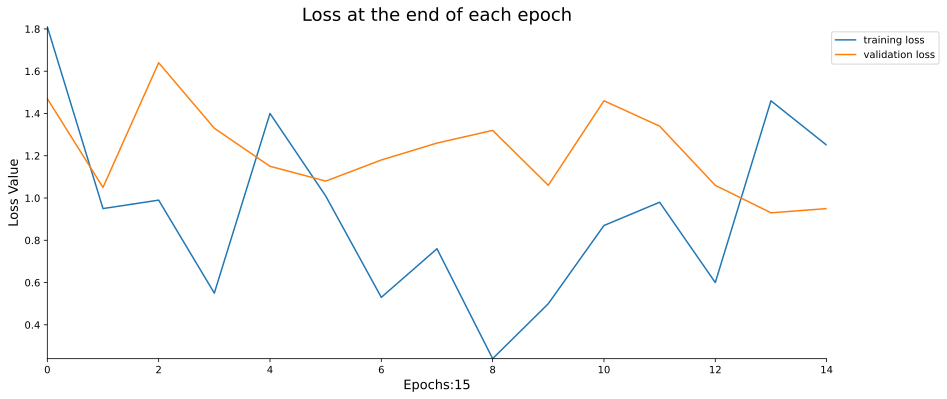

In [51]:
plt.figure(figsize=(14,6))

plt.plot(np.arange(epochs),torch.stack(train_losses).cpu().detach().numpy().round(2),label='training loss')
# plt.plot([loss.item() for loss in train_losses],
#          label='training loss')

plt.plot(np.arange(epochs),torch.stack(test_losses).cpu().detach().numpy().round(2), label='validation loss')
# plt.plot([loss.item() for loss in test_losses],
#          label='validation loss')
plt.title('Loss at the end of each epoch' , fontsize = 18)
plt.ylabel("Loss Value", fontsize = 13)
plt.xlabel("Epochs:15" , fontsize = 13)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.autoscale(enable=True , axis='both', tight=True)

plt.legend(bbox_to_anchor = (1,1), loc = 'upper left')
plt.show()

In [52]:
[t.cpu().detach().numpy().round(2)/500 for t in train_correct]

[np.float64(38.724),
 np.float64(50.418),
 np.float64(55.156),
 np.float64(58.158),
 np.float64(60.722),
 np.float64(62.458),
 np.float64(64.03),
 np.float64(65.3),
 np.float64(66.4),
 np.float64(67.136),
 np.float64(68.1),
 np.float64(68.838),
 np.float64(69.71),
 np.float64(70.34),
 np.float64(70.918)]

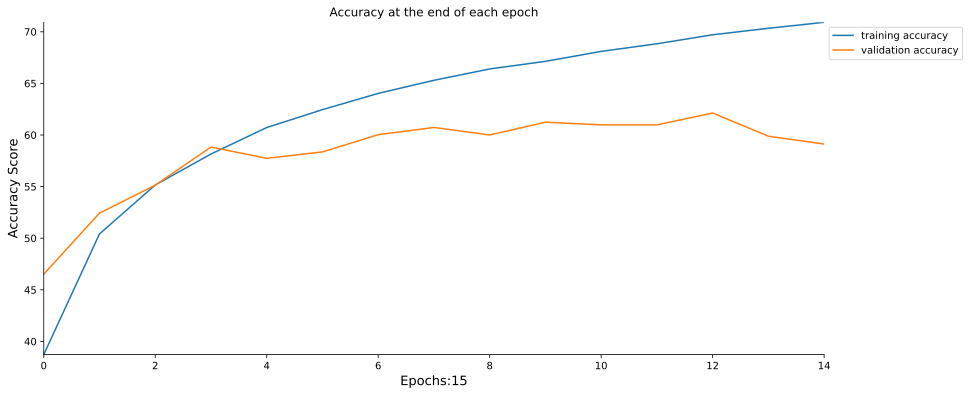

In [53]:
plt.figure(figsize=(14,6))
plt.plot([t.cpu().detach().numpy().round(2)/500 for t in train_correct], label='training accuracy')
plt.plot([t.cpu().detach().numpy().round(2)/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')


plt.ylabel("Accuracy Score", fontsize = 13)
plt.xlabel("Epochs:15" , fontsize = 13)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.autoscale(enable=True , axis='both', tight=True)

plt.legend(bbox_to_anchor = (1,1), loc = 'upper left')
plt.show()

## Evaluate Test Data

In [54]:
print(test_correct) # contains the results of all 10 epochs
print()
print(f'Test accuracy: {test_correct[-1].item()*100/10000:.3f}%') # print the most recent result as a percent

[tensor(4652, device='cuda:0'), tensor(5243, device='cuda:0'), tensor(5514, device='cuda:0'), tensor(5883, device='cuda:0'), tensor(5774, device='cuda:0'), tensor(5836, device='cuda:0'), tensor(6003, device='cuda:0'), tensor(6073, device='cuda:0'), tensor(6000, device='cuda:0'), tensor(6124, device='cuda:0'), tensor(6098, device='cuda:0'), tensor(6098, device='cuda:0'), tensor(6213, device='cuda:0'), tensor(5988, device='cuda:0'), tensor(5912, device='cuda:0')]

Test accuracy: 59.120%


In [55]:
# Extract the data all at once, not in batches
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

In [56]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        y_val = model(X_test)  # we don't flatten the data this time
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()
print(f'Test accuracy: {correct.item()}/{len(test_data)} = {correct.item()*100/(len(test_data)):7.3f}%')

Test accuracy: 5912/10000 =  59.120%


This is not as impressive as with MNIST, which makes sense. We would have to adjust our parameters to obtain better results.<br>
Still, it's much better than the 10% we'd get with random chance!

## Display the confusion matrix
In order to map predictions against ground truth, we need to run the entire test set through the model.<br>
Also, since our model was not as accurate as with MNIST, we'll use a <a href='https://seaborn.pydata.org/generated/seaborn.heatmap.html'>heatmap</a> to better display the results.

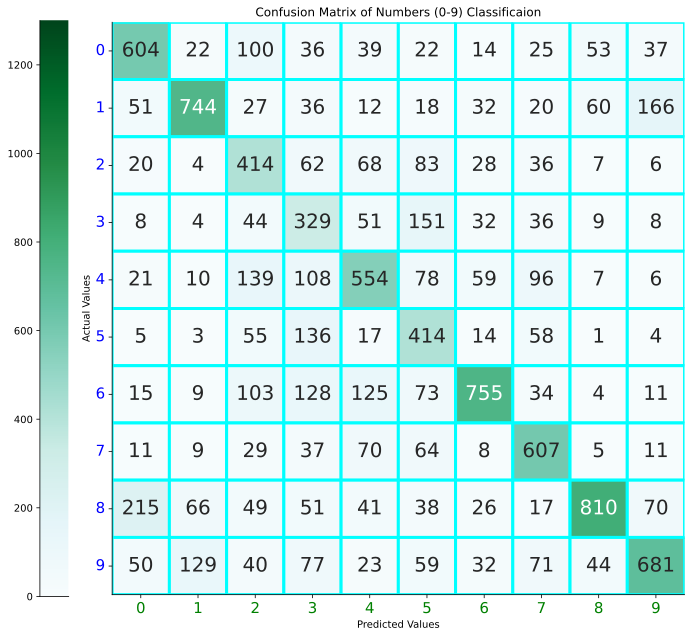

In [57]:
plt.figure(figsize=(13,13))
sns.heatmap(data = confusion_matrix(predicted.cpu().view(-1) , y_test.cpu().view(-1)),
            cmap ="BuGn",
            vmin = 0,
            vmax = 1300,
            annot = True,
            annot_kws = {"size":20},
            linewidths = 3,
            linecolor = "cyan",
            xticklabels=list(range(10)),
            yticklabels=list(range(10)),
            square = True,
            fmt ="g",
            cbar_kws = {"shrink" : 0.8 ,
                        "pad" : 0.06  ,
                        "location" : "left" ,
                        "orientation" : "vertical"}
            ).set(
                xlabel = "Predicted Values",
                ylabel = "Actual Values",
                title = "Confusion Matrix of Numbers (0-9) Classificaion",
            )
plt.yticks(rotation=0 , fontsize = 15, color ="blue")
plt.xticks(fontsize = 15, color ="green")
sns.despine()

For more info on the above chart, visit the docs on <a href='https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html'>scikit-learn's confusion_matrix</a>, <a href='https://seaborn.pydata.org/generated/seaborn.heatmap.html'>seaborn heatmaps</a>, and <a href='https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html'>matplotlib colormaps</a>.

## Examine the misses
We can track the index positions of "missed" predictions, and extract the corresponding image and label. We'll do this in batches to save screen space.

In [58]:
misses = np.array([])
for i in range(len(predicted.view(-1))):
    if predicted[i] != y_test[i]:
        misses = np.append(misses,i).astype('int64')

# Display the number of misses
len(misses)

4088

In [59]:
# Display the first 8 index positions
misses[:8]

array([    3,     4,    12,    17,    24,    25,    31,    35])

In [60]:
# Set up an iterator to feed batched rows
r = 8   # row size
row = iter(np.array_split(misses,len(misses)//r+1))

Now that everything is set up, run and re-run the cell below to view all of the missed predictions.<br>
Use <kbd>Ctrl+Enter</kbd> to remain on the cell between runs. You'll see a <tt>StopIteration</tt> once all the misses have been seen.

Index: [    3     4    12    17    24    25    31    35]
Label: [    0     6     5     7     5     2     5     2]
Class:  plane  frog   dog horse   dog  bird   dog  bird

Guess: [    8     4     6     1     4     9     2     3]
Class:   ship  deer  frog   car  deer truck  bird   cat


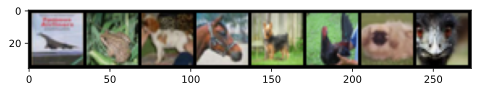

In [61]:
np.set_printoptions(formatter=dict(int=lambda x: f'{x:5}')) # to widen the printed array

nextrow = next(row)
lbls = y_test.cpu().index_select(0,torch.tensor(nextrow)).numpy()
gues = predicted.cpu().index_select(0,torch.tensor(nextrow)).numpy()
print("Index:", nextrow)
print("Label:", lbls)
print("Class: ", *np.array([class_names[i] for i in lbls]))
print()
print("Guess:", gues)
print("Class: ", *np.array([class_names[i] for i in gues]))

images = X_test.cpu().index_select(0,torch.tensor(nextrow))
im = make_grid(images, nrow=r)
plt.figure(figsize=(8,4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

<div class="alert alert-info"><font color=blue><h2>Optional: Load a Saved Model</h2>
In the event that training the ConvolutionalNetwork takes too long, you can load a trained version by running the following code:</font>
<pre style='background-color:rgb(217,237,247)'>
model2 = ConvolutionalNetwork()
model2.load_state_dict(torch.load('CIFAR10-CNN-Model-master.pt'))
model2.eval()</pre>
</div>

In [74]:
from google.colab import files
model_upload = files.upload()

Saving CIFAR10-CNN-Model-master.pt to CIFAR10-CNN-Model-master.pt


In [76]:
# Instantiate the model and load saved parameters
model2 = ConvolutionalNetwork()
model2.load_state_dict(torch.load('CIFAR10-CNN-Model-master.pt'))
model2.eval()

ConvolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [77]:
# Evaluate the saved model against the test set
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model2(X_test)
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()

print(f'Test accuracy: {correct.item()}/{len(test_data)} = {correct.item()*100/(len(test_data)):7.3f}%')

Test accuracy: 6105/10000 =  61.050%


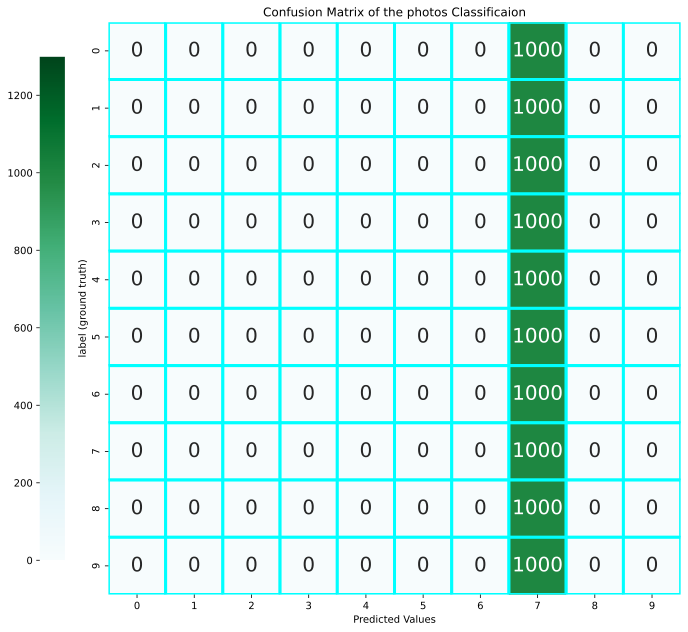

In [73]:
# Display the confusion matrix as a heatmap
arr = confusion_matrix(y_test.view(-1), predicted.view(-1))
df_cm = pd.DataFrame(arr, class_names, class_names)
plt.figure(figsize = (13,13))
#sns.heatmap(df_cm, annot=True, fmt="d", cmap='BuGn')
sns.heatmap(data = df_cm,
            cmap ="BuGn",
            vmin = 0,
            vmax = 1300,
            annot = True,
            annot_kws = {"size":20},
            linewidths = 3,
            linecolor = "cyan",
            xticklabels=list(range(10)),
            yticklabels=list(range(10)),
            square = True,
            fmt ="d",
            cbar_kws = {"shrink" : 0.7 ,
                        "pad" : 0.06  ,
                        "location" : "left" ,
                        "orientation" : "vertical"}
            ).set(
                xlabel = "Predicted Values",
                ylabel = "label (ground truth)",
                title = "Confusion Matrix of the photos Classificaion",
            )

plt.show()

## Great job!